Implementing the Game of life by Conway.
We should use a numpy array of zeros and ones to model the world our cells live in. Furthermore there has to be a function which determins the time evolution of the system accordingly to the rules.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from IPython.display import HTML

Here wehave the rules and the animation.

In [3]:
N = 500
frames = 200
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

#world = np.random.randint(0, 2, (N, N))
# for i in range(T):
#     world = evolve(world)

# fig, ax = plt.subplots(figsize=(6,6))
# ax.axis('off')
# img = ax.imshow(np.zeros((N,N,3)), interpolation='nearest')

# def update(frame):
#     global world
#     world = evolve(world)
#     rgb = np.zeros((N,N,3))
#     rgb[world==1] = [0, 1, 1]
#     rgb[world==0] = [0, 0, 0]
#     img.set_data(rgb)
#     return [img]

# ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)

# HTML(ani.to_jshtml())



Density vs time. Initial density is a crucial parameter.

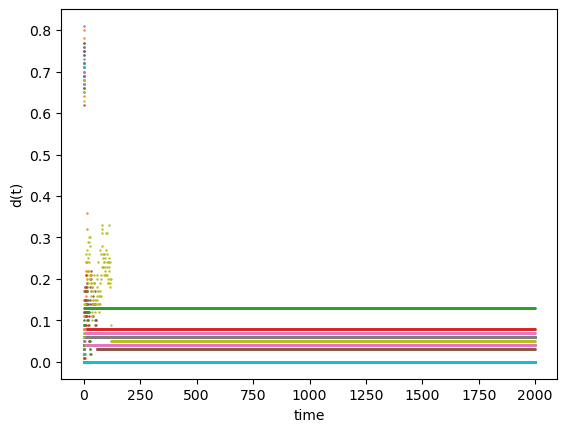

In [28]:
N = 10
T = 2000
trajectories = 50
time = np.arange(T)
initial_density = 0.7
densities = []
for i in range(trajectories):
    aux_density = []
    world = np.random.random((N,N))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world == 1)/N**2)
        world = evolve(world)
    plt.scatter(time,aux_density, s = 0.5)
    densities.append(aux_density)
plt.xlabel("time")
# plt.xlim(200,T)
# plt.ylim(0,0.2)
plt.ylabel("d(t)")
plt.show()
densities = np.array(densities)

How are the trajectories distributed over the phase space?

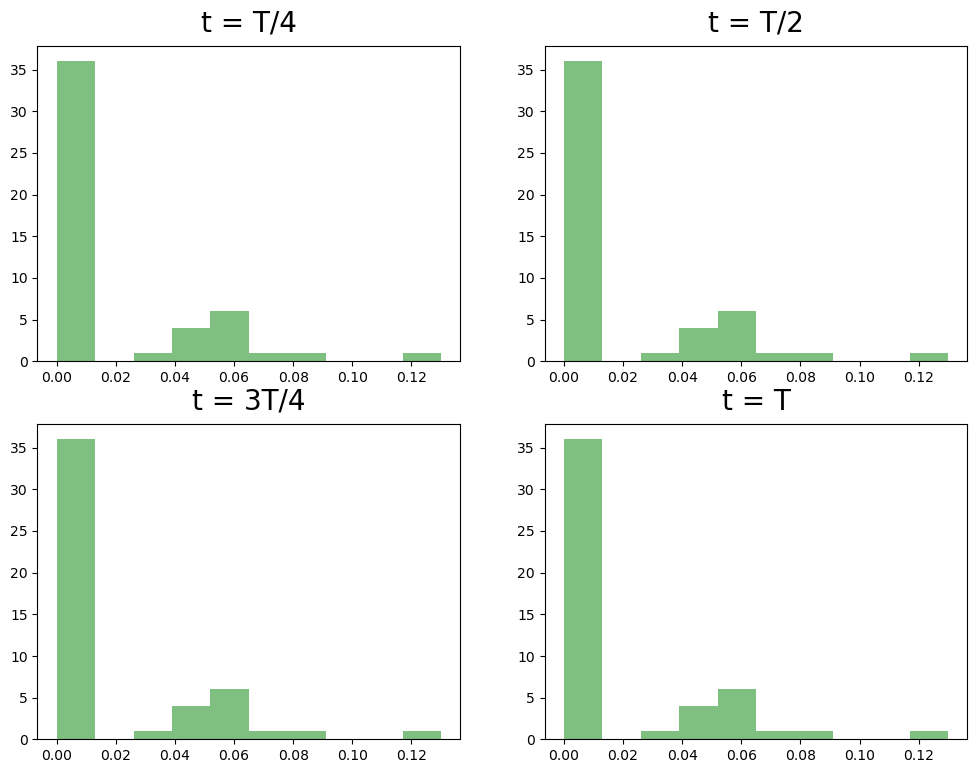

In [29]:

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 9))

ax[0][0].hist(densities[:,int(T/4)],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[0][0].yaxis.set_major_locator(MultipleLocator(2))
# ax[0][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][0].set_title("t = T/4", fontsize=20, verticalalignment='bottom')

ax[0][1].hist(densities[:,int(T/2)],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[0][1].yaxis.set_major_locator(MultipleLocator(2))
# ax[0][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][1].set_title("t = T/2", fontsize=20, verticalalignment='bottom')

ax[1][0].hist(densities[:,int(3*T/4)],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[1][0].yaxis.set_major_locator(MultipleLocator(2))
# ax[1][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][0].set_title("t = 3T/4", fontsize=20, verticalalignment='bottom')

ax[1][1].hist(densities[:,T-1],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[1][1].yaxis.set_major_locator(MultipleLocator(2))
# ax[1][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][1].set_title("t = T", fontsize=20, verticalalignment='bottom')
plt.show()

We can use mean and std and analyze them.

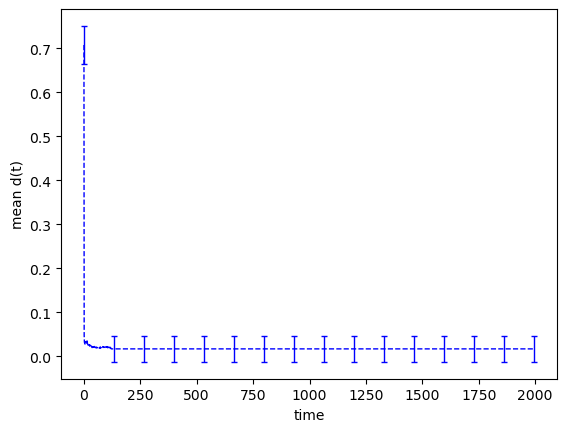

In [30]:
mean_density = densities.mean(axis=0)
std_density = densities.std(axis=0)
idx = list(range(0,T,int(T/15)))
plt.errorbar(time[idx],mean_density[idx],std_density[idx], ls = '', lw = 1, capsize = 2, color = 'blue')
plt.plot(time,mean_density, ls = '--', lw = 1, color = 'blue')
plt.xlabel("time")
plt.ylabel("mean d(t)")
plt.show()

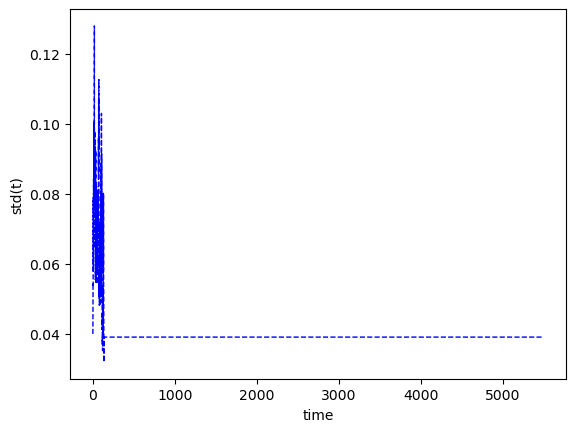

In [27]:
plt.plot(time, std_density, ls = '--', lw = 1, color = 'blue')
#plt.scatter(time[idx], std_density[idx], s = 5, color = 'blue')
plt.xlabel("time")
plt.ylabel("std(t)")
plt.show()

Now we study the asymptotic density.

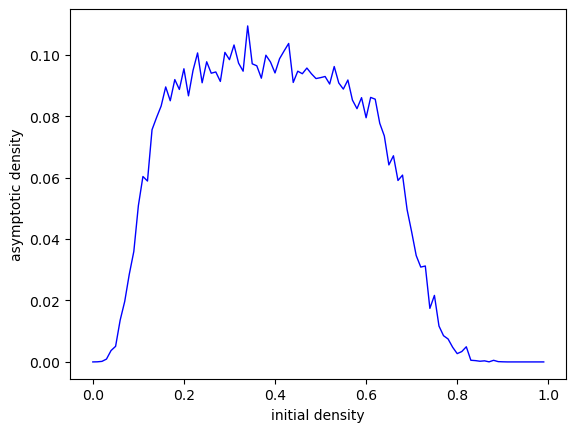

In [19]:
N = 180
T = 1800
trajectories = 5
initial_density = np.arange(0,1,0.05)
asymptotic_density = []
for i_d in initial_density:
    aux_d = 0
    for i in range(trajectories):
        world = world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        aux_d += (1/trajectories)*np.sum(world==1)/N**2
    asymptotic_density.append(aux_d)
plt.plot(initial_density, asymptotic_density, lw = 1, color = 'blue')
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()

What about the rate of change?

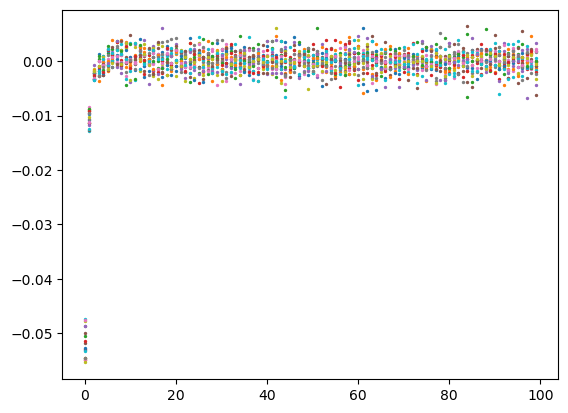

In [20]:
N = 100
T = 100
trajectories = 20
time = np.arange(T)
initial_density = 0.1
densities = []
rate_of_change = []
for i in range(trajectories):
    aux_density = []
    aux_rate = []
    world = np.random.random((N,N))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world == 1)/N**2)
        world = evolve(world)
        aux_rate.append(np.sum(world == 1)/N**2-aux_density[j])
    densities.append(aux_density)
    rate_of_change.append(aux_rate)
densities = np.array(densities)
rate_of_change = np.array(rate_of_change)
for i in range(len(rate_of_change)):
    plt.scatter(time,rate_of_change[i], s = 2)
plt.show()

We saw that starting from an initial density in the range of 0.1-0.7 for large t we reach a steady state around 0.025. What large t means is still not clear, but based on our observations and on the article of interest t = 8000 should be sufficient. At this point we start from a fixed initial density and we generate many trajectories. For each of them we calculate d(large t) as the mean over time of d(t) for 8000 < t < 9000. We then calculate d* as the mean over all trajectories of the latter quantity. It is interesting to understand how d(t) approaches d* depending on the size of the lattice. 

### Determining d*

In [ ]:
initial_density = 0.4
#L = np.array([80,150,300,500,800])
L=np.array([50,100])
def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

T = 9000
DT = 500
trajectories = 10
time = np.arange(T,T+DT)

#final_d = 0
for l in L:
    print("Lattice size: ", l,"x", l)
    densities = []
    for i in range(trajectories):
        aux_density = []
        world = np.random.random((l,l))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        for j in range(T,T+DT):
            world = evolve(world)
            #final_d += 1/(trajectories*DT)*np.sum(world == 1)/l**2
            aux_density.append(np.sum(world == 1)/l**2)
        densities.append(aux_density)
    densities = np.array(densities)
    print("mean: ", np.mean(densities))
    print("std: ", np.std(densities))

Lattice size:  50 x 50
mean:  0.03092
std:  0.008000099999375008
Lattice size:  100 x 100
